# Kalman Filter Tuning Diagnostics — R Measurement Runs

Analyzes `r_measurement_20_{extend,retract}_{1,10,100}ms.csv` logs (constant PWM=20, actuator running
open-loop through the Kalman filter). Columns: `time, delta_t, pwm, position_reading, position_estimate, velocity_estimate`.

Goal: use the **post-fit residual** `e_k = position_reading - position_estimate` to diagnose whether
Q or R is mistuned, and in which direction.

Key diagnostic: for a correctly tuned KF, the post-fit residual should behave like white noise with a
1-lag autocorrelation near 0. A strongly positive, slowly-decaying autocorrelation means the filter is
**not trusting the measurement enough** (Q too small relative to R, or R too large) and is lagging the
true dynamics — the classic "sluggish filter" signature.

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 4)

FILES = {
#     'extend_1ms':    'r_measurement_20_extend_1ms.csv',
#     'extend_10ms':   'r_measurement_20_extend_10ms.csv',
    'extend_20_100ms':  'r_measurement_20_extend_100ms.csv',
    'extend_45_100ms':  'r_measurement_45_extend_100ms.csv',
#     'retract_1ms':   'r_measurement_20_retract_1ms.csv',
#     'retract_10ms':  'r_measurement_20_retract_10ms.csv',
    'retract_20_100ms': 'r_measurement_20_retract_100ms.csv',
    'retract_45_100ms':  'r_measurement_45_retract_100ms.csv',
}
DATA_DIR = './'

def load(fname):
    # Files are UTF-16 (BOM) encoded, comma-separated, with spaces after commas in the header.
    df = pd.read_csv(DATA_DIR + fname, encoding='utf-16')
    df.columns = [c.strip() for c in df.columns]
    df['residual'] = df['position_reading'] - df['position_estimate']
    # numerical derivative of the raw reading as an independent estimate of velocity
    df['raw_velocity'] = df['position_reading'].diff() / df['delta_t']
    return df

data = {name: load(f) for name, f in FILES.items()}
{name: len(df) for name, df in data.items()}

{'extend_20_100ms': 775,
 'extend_45_100ms': 362,
 'retract_20_100ms': 716,
 'retract_45_100ms': 571}

## 1. Residual (innovation) summary statistics

In [18]:
def lag_autocorr(x, lag=1):
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    return np.sum(x[:-lag] * x[lag:]) / np.sum(x**2)

rows = []
for name, df in data.items():
    r = df['residual'].values
    rows.append({
        'run': name,
        'n': len(df),
        'dt_mean_ms': df['delta_t'].mean()*1000,
        'resid_mean': r.mean(),
        'resid_std': r.std(),
        'resid_ac1': lag_autocorr(r, 1),
        'resid_ac5': lag_autocorr(r, 5),
    })
summary = pd.DataFrame(rows).set_index('run')
summary.round(4)

,n,dt_mean_ms,resid_mean,resid_std,resid_ac1,resid_ac5
run,,,,,,
extend_20_100ms,775,99.8723,-0.0119,0.1774,0.7405,0.3129
extend_45_100ms,362,99.7268,-0.0621,0.5381,0.9051,0.1930
retract_20_100ms,716,99.8614,0.0155,0.1488,0.5182,0.2524
retract_45_100ms,571,99.8265,0.0531,0.3645,0.8978,0.3951


**Reading this table:**
- `resid_std` — how far the raw reading typically sits from the filter's estimate. If this is much
  larger than the sensor's true measurement noise, the filter is smoothing too aggressively (R too high
  or Q too low).
- `resid_ac1` / `resid_ac5` — lag-1 / lag-5 autocorrelation of the residual. A well-tuned filter should
  have this close to 0 (white residual). Values close to 1 mean the residual is a slowly-varying,
  structured signal rather than noise — the filter is systematically lagging the true trajectory.

## 2. Autocorrelation function (ACF) of the residual

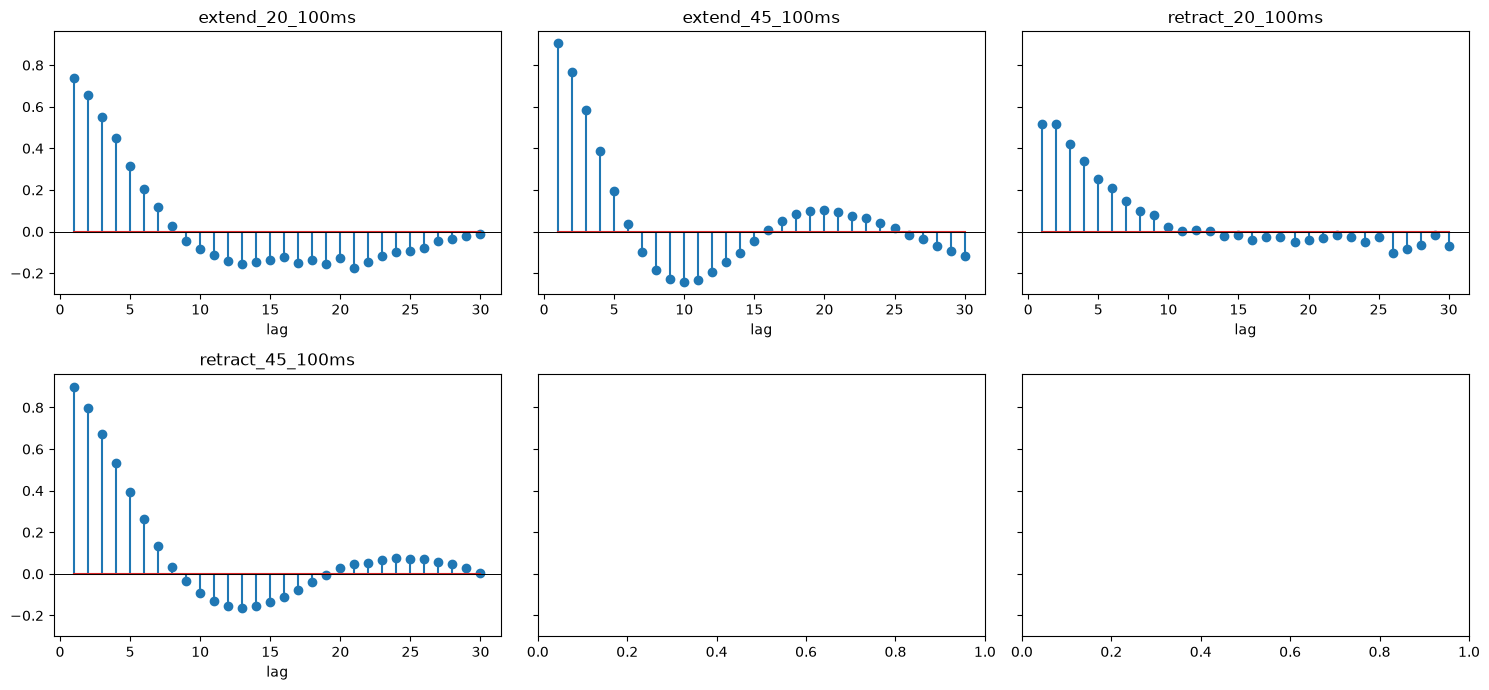

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharey=True)
max_lag = 30
for ax, (name, df) in zip(axes.flat, data.items()):
    r = df['residual'].values
    acs = [lag_autocorr(r, k) for k in range(1, max_lag+1)]
    ax.stem(range(1, max_lag+1), acs)
    ax.axhline(0, color='k', linewidth=0.7)
    ax.set_title(name)
    ax.set_xlabel('lag')
plt.tight_layout()
plt.show()

If the bars decay quickly to ~0 within a few lags, the residual is essentially white and R/Q are
reasonably matched. If the bars stay high (>0.3-0.5) across many lags, the residual has structure the
filter isn't using — a mistuning symptom.

## 3. Position: raw reading vs. filter estimate

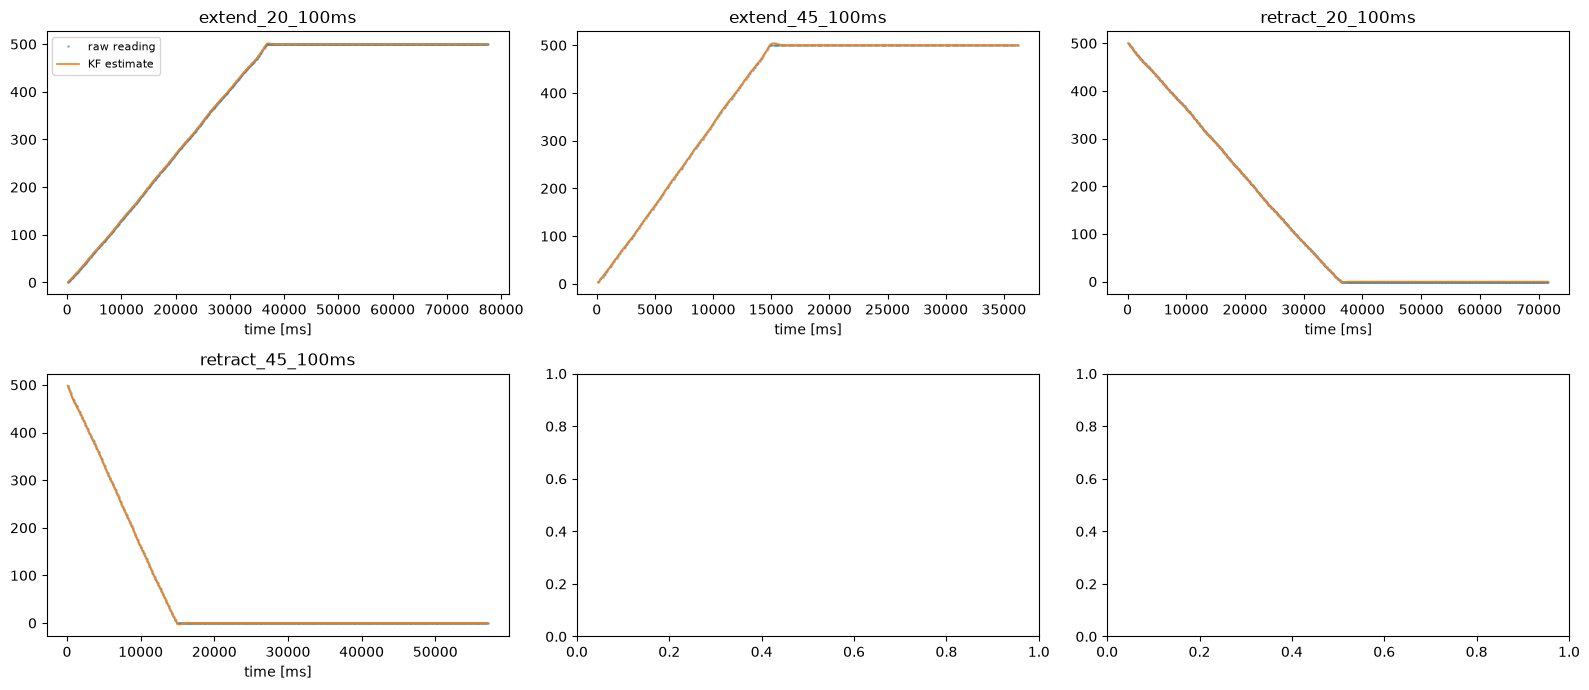

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(16, 7), sharey=False)
for ax, (name, df) in zip(axes.flat, data.items()):
    ax.plot(df['time'], df['position_reading'], '.', ms=2, alpha=0.4, label='raw reading')
    ax.plot(df['time'], df['position_estimate'], '-', linewidth=1.2, label='KF estimate')
    ax.set_title(name)
    ax.set_xlabel('time [ms]')
axes.flat[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 4. Velocity: KF estimate vs. raw numerical derivative

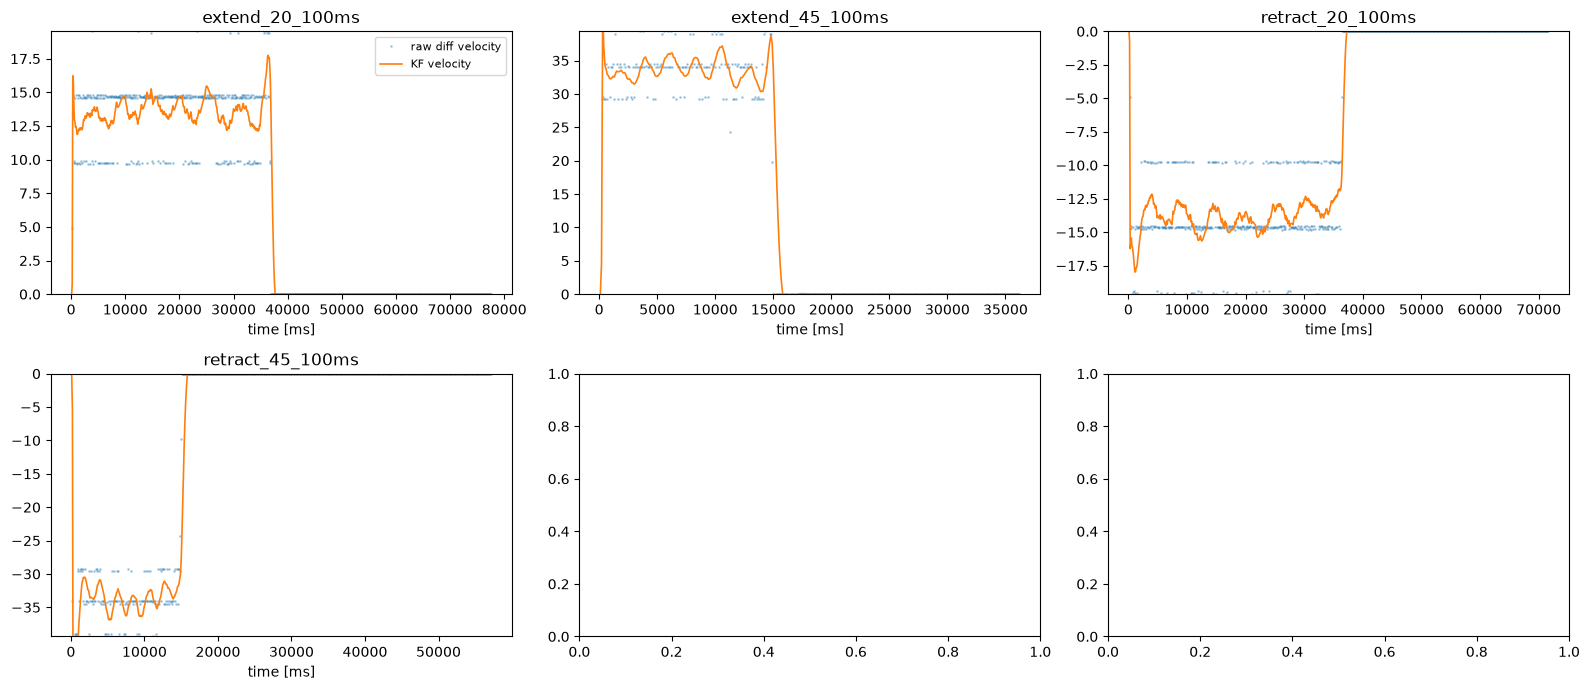

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(16, 7))
for ax, (name, df) in zip(axes.flat, data.items()):
    ax.plot(df['time'], df['raw_velocity'], '.', ms=2, alpha=0.3, label='raw diff velocity')
    ax.plot(df['time'], df['velocity_estimate'], '-', linewidth=1.2, label='KF velocity')
    ax.set_title(name)
    ax.set_xlabel('time [ms]')
    ax.set_ylim(np.nanpercentile(df['raw_velocity'], [1, 99]))
axes.flat[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

If `KF velocity` is much smoother than, and visibly lags behind, jumps in the raw diff velocity,
the filter is over-smoothing (again: Q too small relative to R). If the KF velocity is as noisy as the
raw derivative, Q is too large relative to R (filter trusts noisy measurements too much).

## 5. Cross-check: does behavior change with logging period?

In [22]:
summary_by_dt = summary.copy()
summary_by_dt['direction'] = ['extend' if 'extend' in i else 'retract' for i in summary_by_dt.index]
summary_by_dt.sort_values(['direction', 'dt_mean_ms'])[['dt_mean_ms', 'resid_std', 'resid_ac1']]

,dt_mean_ms,resid_std,resid_ac1
run,,,
extend_45_100ms,99.726818,0.538050,0.905072
extend_20_100ms,99.872335,0.177415,0.740494
retract_45_100ms,99.826494,0.364537,0.897805
retract_20_100ms,99.861402,0.148810,0.518204


If `resid_ac1` stays high (~0.95+) across all three logging periods (1/10/100 ms) and both
directions, the correlation is not an artifact of sampling rate — it is a real property of the filter's
Q/R balance and needs to be fixed by re-tuning, not by changing the loop rate.

## 6. Automatic verdict

In [23]:
ac1_mean = summary['resid_ac1'].mean()
std_mean = summary['resid_std'].mean()

print(f"Mean resid_ac1 across all runs: {ac1_mean:.3f}")
print(f"Mean resid_std across all runs: {std_mean:.3f}")
print()

if ac1_mean > 0.5:
    print("VERDICT: Residuals are strongly autocorrelated across every run and sample rate.")
    print("This means the filter is lagging the true trajectory instead of tracking it.")
    print("-> Increase Q (process noise) and/or decrease R (measurement noise) so the filter")
    print("   trusts new measurements more and closes the gap faster.")
elif ac1_mean < -0.3:
    print("VERDICT: Residuals oscillate sign lag-to-lag (negative autocorrelation).")
    print("-> The filter is overreacting to noise. Decrease Q and/or increase R.")
else:
    print("VERDICT: Residual autocorrelation is close to zero -> Q/R are reasonably balanced.")
    print("Focus on matching resid_std to your actual sensor noise for finer tuning.")

Mean resid_ac1 across all runs: 0.765
Mean resid_std across all runs: 0.307

VERDICT: Residuals are strongly autocorrelated across every run and sample rate.
This means the filter is lagging the true trajectory instead of tracking it.
-> Increase Q (process noise) and/or decrease R (measurement noise) so the filter
   trusts new measurements more and closes the gap faster.
